### Chapter 17

**Ch17 Predicting probability of firm exit**

using the bosnide dataset

version 1.0 2024-01-15

In [3]:
import os
import pandas as pd
import numpy as np
import sys
import patsy
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
import sklearn.metrics as metrics
from sklearn.metrics import brier_score_loss, roc_curve, auc, confusion_matrix, roc_auc_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from plotnine import *
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

### Define helper functions

In [4]:
def regression_results(y_true, y_pred):

    # Regression metrics
    explained_variance=metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error=metrics.mean_absolute_error(y_true, y_pred) 
    mse=metrics.mean_squared_error(y_true, y_pred) 
    median_absolute_error=metrics.median_absolute_error(y_true, y_pred)
    r2=metrics.r2_score(y_true, y_pred)

    print('explained_variance: ', round(explained_variance,4))    
    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))
    
def create_coef_matrix(X, model):
    coef_matrix = pd.concat(
        [pd.DataFrame(X.columns),pd.DataFrame(model.coef_.flatten())], axis = 1
    )
    coef_matrix.columns = ['variable', 'coefficient']
    coef_matrix.iloc[-1] = ['Intercept', model.intercept_.flatten()[0]]
    return coef_matrix

def cv_summary(lambdas, C_values, model):
    d = {'lambdas': lambdas, 'C_values': C_values, 'mean_cv_score': model.scores_[1].mean(axis = 0)}
    return(pd.DataFrame(data=d))

def create_roc_plot(y_true, y_pred):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    all_coords = pd.DataFrame({
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds
    })
    
    plot = ggplot(all_coords, aes(x = 'fpr', y = 'tpr')) \
        + geom_line(color=color[0], size = 0.7) \
        + geom_area(position = 'identity', fill = 'mediumaquamarine', alpha = 0.3) \
        + xlab("False Positive Rate (1-Specifity)") \
        + ylab("True Positive Rate (Sensitivity)") \
        + geom_abline(intercept = 0, slope = 1,  linetype = "dotted", color = "black") \
        + scale_y_continuous(limits = (0, 1), breaks = seq(0, 1, .1), expand = (0, 0.01)) \
        + scale_x_continuous(limits = (0, 1), breaks = seq(0, 1, .1), expand = (0.01, 0)) \
        + theme_bw()
    return(plot)

def sigmoid_array(x):
    return(1 / (1 + np.exp(-x)))

def generate_fold_prediction(model, X, fold, param_index):
    fold_coef = model.coefs_paths_[1][fold,param_index,:]
    return(sigmoid_array(np.dot(X, np.transpose(fold_coef)[:-1]) +  np.transpose(fold_coef)[-1]))

def create_loss_plot(all_coords, optimal_threshold, curr_exp_loss):
    all_coords_copy = all_coords.copy()
    all_coords_copy['loss'] = (all_coords_copy.false_pos*FP + all_coords_copy.false_neg*FN)/all_coords_copy.n
    
    t = optimal_threshold
    l = curr_exp_loss
    
    plot = ggplot(all_coords_copy, aes(x = 'thresholds', y = 'loss')) + \
        geom_line(color=color[0], size=0.7) + \
        scale_x_continuous(breaks = seq(0, 1.1, by = 0.1)) + \
        coord_cartesian(xlim=(0,1))+ \
        geom_vline(xintercept = t , color = color[0] ) + \
        annotate(geom = "text", x = t - 0.01, y= max(all_coords_copy.loss) - 0.4,
                 label="best threshold: " + str(round(t,2)),
                 colour=color[1], angle=90, size = 7) +\
        annotate(geom = "text", x = t + 0.06, y= l,\
                 label= str(round(l, 2)), size = 7) +\
        theme_bw()
    return(plot)


def create_roc_plot_with_optimal(all_coords, optimal_threshold):
    all_coords_copy = all_coords.copy()
    all_coords_copy['sp'] = all_coords_copy.true_neg/all_coords_copy.neg
    all_coords_copy['se'] = all_coords_copy.true_pos/all_coords_copy.pos
    
    best_coords = all_coords_copy[all_coords_copy.thresholds == optimal_threshold]
    sp = best_coords.sp.values[0]
    se = best_coords.se.values[0]

    plot = ggplot(all_coords_copy, aes(x = 'sp', y = 'se')) +\
        geom_line(color=color[0], size=0.7) +\
        scale_y_continuous(breaks = seq(0, 1.1, by = 0.1)) +\
        scale_x_reverse(breaks = seq(0, 1.1, by = 0.1)) +\
        geom_point(data = pd.DataFrame({'sp': [sp], 'se': [se]})) +\
        annotate(geom = "text", x = sp, y = se + 0.03,
                 label = str(round(sp, 2)) + ', ' + str(round(se, 2)), size = 7) +\
        theme_bw()
    return(plot)

### Get Data

In [5]:
# Import the prewritten helper functions
from py_helper_functions import *

In [7]:
# DATA IMPORT - FROM FILE
data = pd.read_csv('bisnode_firms_clean_elene.csv')

In [8]:
data.head()

,year,comp_id,begin,end,amort,curr_assets,curr_liab,extra_exp,extra_inc,extra_profit_loss,...,flag_miss_ceo_age,ceo_young,labor_avg_mod,flag_miss_labor_avg,default_f,sales_mil_log_sq,flag_low_d1_sales_mil_log,flag_high_d1_sales_mil_log,d1_sales_mil_log_mod,d1_sales_mil_log_mod_sq
0,2012,1001541.0,2012-01-01,2012-12-31,481.481476,9629.629883,1303.703735,0.0,0.000000,0.000000,...,0,1,0.621691,1,fast_growth,45.190017,1,0,-1.500000,2.250000
1,2012,1002029.0,2012-01-01,2012-12-31,14929.629883,203885.187500,120444.453125,0.0,0.000000,0.000000,...,0,1,0.458333,0,no_fast_growth,0.016375,0,0,0.684448,0.468469
2,2012,1003200.0,2012-01-01,2012-12-31,25.925926,22.222221,10996.295898,0.0,0.000000,0.000000,...,1,0,0.621691,1,no_fast_growth,34.614876,0,0,-1.424773,2.029978
3,2012,1011889.0,2012-01-01,2012-12-31,36625.925781,160166.671875,18911.111328,0.0,0.000000,0.000000,...,0,0,1.621212,0,no_fast_growth,0.698025,0,0,0.097722,0.009550
4,2012,1014183.0,2012-01-01,2012-12-31,12551.851562,199903.703125,8274.074219,0.0,7.407407,7.407407,...,0,0,0.715278,0,no_fast_growth,4.171000,0,0,-0.273087,0.074577


In [9]:
data.columns.tolist()

['year',
 'comp_id',
 'begin',
 'end',
 'amort',
 'curr_assets',
 'curr_liab',
 'extra_exp',
 'extra_inc',
 'extra_profit_loss',
 'fixed_assets',
 'inc_bef_tax',
 'intang_assets',
 'inventories',
 'liq_assets',
 'material_exp',
 'personnel_exp',
 'profit_loss_year',
 'sales',
 'share_eq',
 'subscribed_cap',
 'tang_assets',
 'D',
 'balsheet_flag',
 'balsheet_length',
 'balsheet_notfullyear',
 'founded_year',
 'exit_year',
 'ceo_count',
 'foreign',
 'female',
 'birth_year',
 'inoffice_days',
 'gender',
 'origin',
 'nace_main',
 'ind2',
 'ind',
 'urban_m',
 'region_m',
 'founded_date',
 'exit_date',
 'status_alive',
 'sales_future',
 'growth_rate',
 'fast_growth',
 'ln_sales',
 'sales_mil',
 'sales_mil_log',
 'd1_sales_mil_log',
 'age',
 'new',
 'ind2_cat',
 'age2',
 'foreign_management',
 'gender_m',
 'm_region_loc',
 'flag_asset_problem',
 'total_assets_bs',
 'extra_exp_pl',
 'extra_inc_pl',
 'extra_profit_loss_pl',
 'inc_bef_tax_pl',
 'inventories_pl',
 'material_exp_pl',
 'profit_loss

### Define variable sets 

In [10]:
rawvars = ["curr_assets", "curr_liab", "extra_exp", "extra_inc", "extra_profit_loss", "fixed_assets",
              "inc_bef_tax", "intang_assets", "inventories", "liq_assets", "material_exp", "personnel_exp",
              "profit_loss_year", "sales", "share_eq", "subscribed_cap"]
qualityvars = ["balsheet_flag", "balsheet_length", "balsheet_notfullyear"]
engvar = ["total_assets_bs", "fixed_assets_bs", "liq_assets_bs", "curr_assets_bs",
            "share_eq_bs", "subscribed_cap_bs", "intang_assets_bs", "extra_exp_pl",
            "extra_inc_pl", "extra_profit_loss_pl", "inc_bef_tax_pl", "inventories_pl",
            "material_exp_pl", "profit_loss_year_pl", "personnel_exp_pl"]
engvar2 = ["extra_profit_loss_pl_quad", "inc_bef_tax_pl_quad",
             "profit_loss_year_pl_quad", "share_eq_bs_quad"]
engvar3 = []
for col in data.columns:
    if col.endswith('flag_low') or col.endswith('flag_high') or col.endswith('flag_error') or col.endswith('flag_zero'):
        engvar3.append(col)


d1 =  ["d1_sales_mil_log_mod", "d1_sales_mil_log_mod_sq",
         "flag_low_d1_sales_mil_log", "flag_high_d1_sales_mil_log"]
hr = ["female", "ceo_age", "flag_high_ceo_age", "flag_low_ceo_age",
        "flag_miss_ceo_age", "ceo_count", "labor_avg_mod",
        "flag_miss_labor_avg", "foreign_management"]

In [11]:
data.ind2_cat.value_counts()

ind2_cat
56.0    11413
55.0     2061
28.0     1790
33.0     1772
26.0      994
27.0      599
29.0      259
30.0      148
Name: count, dtype: int64

See `patsy` formula language [here](https://patsy.readthedocs.io/en/latest/formulas.html), treatment of categorical variables [here](https://patsy.readthedocs.io/en/latest/categorical-coding.html). 

In [12]:
#Creat dummy columns from category variables and drop first level
ind2_catmat = patsy.dmatrix("0 + C(ind2_cat)",data, return_type="dataframe")

In [13]:
ind2_catmat

,C(ind2_cat)[26.0],C(ind2_cat)[27.0],C(ind2_cat)[28.0],C(ind2_cat)[29.0],C(ind2_cat)[30.0],C(ind2_cat)[33.0],C(ind2_cat)[55.0],C(ind2_cat)[56.0]
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
19031,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19032,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
19033,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
19034,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Question: why are we dropping the first level? 

In [15]:
# This will not crash even if [26] is missing
ind2_catmat = ind2_catmat.drop(['C(ind2_cat)[26]'], axis=1, errors='ignore')

In [16]:
data.m_region_loc.value_counts()

m_region_loc
Central    11290
East        4838
West        2908
Name: count, dtype: int64

In [17]:
m_region_locmat = patsy.dmatrix("0 + C(m_region_loc)",data, return_type="dataframe")
m_region_locmat = m_region_locmat.drop(['C(m_region_loc)[Central]'], axis=1)

In [18]:
data.urban_m.value_counts()

urban_m
3.0    7691
1.0    6038
2.0    5307
Name: count, dtype: int64

In [20]:
# Create the dummy matrix
urban_mmat = patsy.dmatrix("0 + C(urban_m)", data, return_type="dataframe")

# Drop the first column by position (index 0) to avoid the dummy variable trap
urban_mmat = urban_mmat.iloc[:, 1:]

In [21]:
# Define X1
basevars = data[["sales_mil_log", "sales_mil_log_sq", "d1_sales_mil_log_mod", "profit_loss_year_pl"]]
X1 = pd.concat([basevars, ind2_catmat], axis=1)

# Define X2
X2additional_vars = data[["fixed_assets_bs", "share_eq_bs","curr_liab_bs", "curr_liab_bs_flag_high", \
                          "curr_liab_bs_flag_error",  "age", "foreign_management"]]
X2 = pd.concat([X1, X2additional_vars], axis=1)

# Define X3
firm = pd.concat([data[["age", "age2", "new"]], ind2_catmat, m_region_locmat, urban_mmat], axis=1)
X3 = pd.concat([data[["sales_mil_log", "sales_mil_log_sq"] + engvar + d1], firm], axis=1)

# Define X4
X4 = pd.concat([data[["sales_mil_log", "sales_mil_log_sq"] + engvar + d1 \
                                 + engvar2 + engvar3 + hr + qualityvars], firm], axis=1)

In [22]:
# Define X5

#Creat matrix for interactions1 variables
int1mat = patsy.dmatrix("0 + C(ind2_cat):age + C(ind2_cat):age2 + C(ind2_cat):d1_sales_mil_log_mod \
                + C(ind2_cat):sales_mil_log + C(ind2_cat):ceo_age + C(ind2_cat):foreign_management \
                + C(ind2_cat):female + C(ind2_cat):C(urban_m) + C(ind2_cat):labor_avg_mod", 
                        data, return_type="dataframe")

#Drop first level to get k-1 dummies out of k categorical levels 
for col in int1mat.columns:
    if col.startswith('C(ind2_cat)[26]') or col.endswith('C(urban_m)[1]'):
        int1mat = int1mat.drop([col], axis=1)
        
#Creat matrix for interactions2 variables        
int2mat = patsy.dmatrix("0 + sales_mil_log:age + sales_mil_log:female + sales_mil_log:profit_loss_year_pl \
                + sales_mil_log:foreign_management", 
                        data, return_type="dataframe")

X5 = pd.concat([X4, int1mat, int2mat], axis=1)

In [23]:
# Define logitvars for LASSO
logitvars = pd.concat([X4, int1mat, int2mat], axis=1)

In [24]:
# Define rfvars for RF (no interactions, no modified features)
rfvars  = pd.concat([data[["sales_mil", "d1_sales_mil_log"] + rawvars + hr + qualityvars], firm], axis=1)

In [25]:
y = data['fast_growth']

### Simple linear and logistic models

**Simplest model: X1**

In [26]:
ols_modelx1 = LinearRegression().fit(X1, y)

In [27]:
regression_results(y, ols_modelx1.predict(X1))

explained_variance:  0.0223
r2:  0.0223
MAE:  0.3247
MSE:  0.1624
RMSE:  0.4029


In [28]:
create_coef_matrix(X1, ols_modelx1)

,variable,coefficient
0,sales_mil_log,-0.008695
1,sales_mil_log_sq,0.003850
2,d1_sales_mil_log_mod,0.020115
3,profit_loss_year_pl,-0.023577
4,C(ind2_cat)[26.0],-0.036899
5,C(ind2_cat)[27.0],0.009221
6,C(ind2_cat)[28.0],-0.017507
7,C(ind2_cat)[29.0],0.078644
8,C(ind2_cat)[30.0],0.071094
9,C(ind2_cat)[33.0],0.004592


In [31]:
glm_modelx1 = LogisticRegression(
    solver="newton-cg", max_iter=1000, penalty=None, random_state=20240205).fit(X1, y)
regression_results(y, glm_modelx1.predict(X1))


explained_variance:  -0.0029
r2:  -0.2675
MAE:  0.2105
MSE:  0.2105
RMSE:  0.4588


On the negative variance: see Wikipedia on [$R^2$](https://en.wikipedia.org/wiki/Coefficient_of_determination).

In [32]:
create_coef_matrix(X1, glm_modelx1)

,variable,coefficient
0,sales_mil_log,-0.080329
1,sales_mil_log_sq,0.017384
2,d1_sales_mil_log_mod,0.113559
3,profit_loss_year_pl,-0.137760
4,C(ind2_cat)[26.0],-0.371335
5,C(ind2_cat)[27.0],-0.099238
6,C(ind2_cat)[28.0],-0.251328
7,C(ind2_cat)[29.0],0.267117
8,C(ind2_cat)[30.0],0.192954
9,C(ind2_cat)[33.0],-0.135748


**Model X2**

In [34]:
glm_modelx2 = LogisticRegression(solver="newton-cg", max_iter=1000, penalty=None).fit(X2, y)
regression_results(y, glm_modelx2.predict(X2))

explained_variance:  -0.0093
r2:  -0.2603
MAE:  0.2093
MSE:  0.2093
RMSE:  0.4575


In [35]:
create_coef_matrix(X2, glm_modelx2)

,variable,coefficient
0,sales_mil_log,-0.076798
1,sales_mil_log_sq,0.017324
2,d1_sales_mil_log_mod,0.060360
3,profit_loss_year_pl,-0.239925
4,C(ind2_cat)[26.0],-0.267107
5,C(ind2_cat)[27.0],-0.003476
6,C(ind2_cat)[28.0],-0.169988
7,C(ind2_cat)[29.0],0.277345
8,C(ind2_cat)[30.0],0.252766
9,C(ind2_cat)[33.0],-0.177853


In [36]:
mx2 = sm.Logit(y,sm.add_constant(X2)).fit().get_margeff()
print(mx2.summary())

Optimization terminated successfully.
         Current function value: 0.492417
         Iterations 6
        Logit Marginal Effects       
Dep. Variable:            fast_growth
Method:                          dydx
At:                           overall
                             dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
sales_mil_log              -0.0122      0.005     -2.491      0.013      -0.022      -0.003
sales_mil_log_sq            0.0027      0.001      3.696      0.000       0.001       0.004
d1_sales_mil_log_mod        0.0096      0.005      1.752      0.080      -0.001       0.020
profit_loss_year_pl        -0.0380      0.009     -4.147      0.000      -0.056      -0.020
C(ind2_cat)[26.0]          -0.0424   1.29e+05  -3.29e-07      1.000   -2.52e+05    2.52e+05
C(ind2_cat)[27.0]          -0.0006   1.29e+05  -4.44e-09      1.000   -2.52e+05    2.52e+05
C(ind2_cat

**Baseline model is X4 (all vars, but no interactions)**

In [37]:
ols_model = LinearRegression().fit(X4, y)
regression_results(y, ols_model.predict(X4))

explained_variance:  0.0685
r2:  0.0685
MAE:  0.3097
MSE:  0.1547
RMSE:  0.3933


In [38]:
create_coef_matrix(X4, ols_model)

,variable,coefficient
0,sales_mil_log,-1.004478e-02
1,sales_mil_log_sq,3.812295e-03
2,total_assets_bs,3.743692e-09
3,fixed_assets_bs,1.602263e-02
4,liq_assets_bs,3.334970e-02
...,...,...
75,C(ind2_cat)[56.0],-8.783125e-02
76,C(m_region_loc)[East],-2.951055e-03
77,C(m_region_loc)[West],-9.928107e-03
78,C(urban_m)[2.0],-2.039772e-02


In [40]:
glm_model = LogisticRegression(solver="newton-cg",max_iter=1000, penalty=None).fit(X4, y)
regression_results(y, glm_model.predict(X4))

explained_variance:  -0.0281
r2:  -0.2372
MAE:  0.2055
MSE:  0.2055
RMSE:  0.4533


In [41]:
create_coef_matrix(X4, glm_model)

,variable,coefficient
0,sales_mil_log,-7.729869e-02
1,sales_mil_log_sq,2.015561e-02
2,total_assets_bs,2.450791e-08
3,fixed_assets_bs,-1.162180e+00
4,liq_assets_bs,2.031570e-01
...,...,...
75,C(ind2_cat)[56.0],-3.924653e-01
76,C(m_region_loc)[East],-1.619180e-02
77,C(m_region_loc)[West],-6.877576e-02
78,C(urban_m)[2.0],-1.326173e-01


In [42]:
# Get marginal effects
m = sm.Logit(y,sm.add_constant(X4)).fit().get_margeff()

         Current function value: 0.481277
         Iterations: 35


In [43]:
type(m)

statsmodels.discrete.discrete_margins.DiscreteMargins

In [44]:
print(m.summary())

        Logit Marginal Effects       
Dep. Variable:            fast_growth
Method:                          dydx
At:                           overall
                                    dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
sales_mil_log                     -0.0119      0.007     -1.754      0.079      -0.025       0.001
sales_mil_log_sq                   0.0031      0.001      3.274      0.001       0.001       0.005
total_assets_bs                 3.789e-09   2.26e-09      1.674      0.094   -6.47e-10    8.22e-09
fixed_assets_bs                   -3.3910   2.25e+04     -0.000      1.000    -4.4e+04     4.4e+04
liq_assets_bs                      0.0314      0.013      2.420      0.016       0.006       0.057
curr_assets_bs                    -3.4457   2.25e+04     -0.000      1.000   -4.42e+04    4.42e+04
share_eq_bs                        0.0177      0.011    

<br> 

**Keep significant variables only**

In [45]:
t = m.summary().tables[1]

In [46]:
t

,dy/dx,std err,z,P>|z|,[0.025,0.975]
sales_mil_log,-0.0119,0.007,-1.754,0.079,-0.025,0.001
sales_mil_log_sq,0.0031,0.001,3.274,0.001,0.001,0.005
total_assets_bs,3.789e-09,2.26e-09,1.674,0.094,-6.47e-10,8.22e-09
fixed_assets_bs,-3.3910,2.25e+04,-0.000,1.000,-4.4e+04,4.4e+04
liq_assets_bs,0.0314,0.013,2.420,0.016,0.006,0.057
curr_assets_bs,-3.4457,2.25e+04,-0.000,1.000,-4.42e+04,4.42e+04
share_eq_bs,0.0177,0.011,1.637,0.102,-0.003,0.039
subscribed_cap_bs,-0.0426,0.014,-2.964,0.003,-0.071,-0.014
intang_assets_bs,-3.4197,2.25e+04,-0.000,1.000,-4.41e+04,4.41e+04
extra_exp_pl,0.1260,0.305,0.413,0.679,-0.471,0.723


In [47]:
columns = pd.DataFrame(t.data).iloc[0].tolist()

In [48]:
df_marginal_effects = pd.DataFrame(t.data, columns = columns).iloc[1:].astype(
    {'dy/dx': float, 'P>|z|': float})
df_marginal_effects[df_marginal_effects['P>|z|'] <= 0.05].sort_values(by = 'dy/dx', ascending = False).reset_index(drop = True)

,,dy/dx,std err,z,P>|z|,[0.025,0.975]
0,inventories_pl,0.0978,0.020,4.904,0.000,0.059,0.137
1,flag_high_ceo_age,0.0893,0.042,2.131,0.033,0.007,0.171
2,material_exp_pl,0.0520,0.019,2.724,0.006,0.015,0.089
3,balsheet_notfullyear,0.0443,0.021,2.147,0.032,0.004,0.085
4,d1_sales_mil_log_mod_sq,0.0426,0.008,5.094,0.000,0.026,0.059
5,foreign_management,0.0401,0.011,3.626,0.000,0.018,0.062
6,liq_assets_bs,0.0314,0.013,2.420,0.016,0.006,0.057
7,new,0.0310,0.010,2.963,0.003,0.011,0.052
8,sales_mil_log_sq,0.0031,0.001,3.274,0.001,0.001,0.005
9,age2,0.0004,8.95e-05,4.998,0.000,0.000,0.001


### Split data into train and holdout

In [49]:
index_train, index_holdout= train_test_split(
    data.index.values, train_size=round(0.8*len(data.index)), random_state=42)

y_train = y.iloc[index_train]
y_holdout = y.iloc[index_holdout]

In [50]:
print('Total')
print(data['fast_growth'].value_counts(normalize=True))
print('Train')
print(data.iloc[index_train]['fast_growth'].value_counts(normalize=True))
print('Holdout')
print(data.iloc[index_holdout]['fast_growth'].value_counts(normalize=True))

Total
fast_growth
0    0.789714
1    0.210286
Name: proportion, dtype: float64
Train
fast_growth
0    0.790334
1    0.209666
Name: proportion, dtype: float64
Holdout
fast_growth
0    0.787234
1    0.212766
Name: proportion, dtype: float64


### Predictions using cross-validations

####  <font color = ' blue'> A digression into optimization algorithms </font>


    
Our task is to find the best parameters that give us the least error in predicting the output. We call the function that calculates this error a **cost function**  or a **loss function**, and our goal is to minimize the error in order to get the best-predicted output. This cost function is usally **quadratic**, either globally with one optimum (simple case) or locally with multiple local optima and one global optima somewhere along the sets of parameters.
- *newton-cg*: It uses a quadratic function minimalization and finds global optimum swiftly. Drawbacks: computationally expensive and stops at the first saddle point.
- *newton-cholesky*: It uses a newton-cg algorithm with a Cholesky decomposition of the Hessian matrix. This solver is more efficient than "newton-cg" for large datasets, as it requires less memory and computational resources. However, it may not converge for some datasets.
- *liblinear*: It is a linear classification that supports logistic regression and linear support vector machine. It applies automatic parameter selection (a.k.a L1 Regularization) and it’s recommended when you have high dimension dataset (recommended for solving large-scale classification problems).
- *lbfgs*: It is a simplified newton-cg which performs better on a limited dataset. It, however, may not converge to anything. 
‘newton-cholesky’, 
- *sag* (stochastic average descent): It optimizes the sum of a finite number of smooth convex functions. Like stochastic gradient (SG) methods, the SAG method's iteration cost is independent of the number of terms in the sum. However, by incorporating a memory of previous gradient values, the SAG method achieves a faster convergence rate than black-box SG methods. Drawbacks: it only supports L2 regularization and it is less practical for large dataset for its memory consumption. 
- *saga* (stochastic average descent): A sag-alternative which supports L2 regularization.

More [here](https://stackoverflow.com/questions/38640109/logistic-regression-python-solvers-definitions)

Supported penalties by solver:

- *lbfgs*: L2
- *liblinear*: L1, L2
- *newton-cg*: L2
- *newton-cholesky*: L2
- *sag*: L2
- *saga*: elasticnet, L1, L2]

#### specify cross-validation method

In [51]:
k = KFold(n_splits = 5, shuffle = True, random_state = 20240205)

#### Logistic regression

In [52]:
# no regularisation needed so setting the paremeter to very high value
Cs_value_logit = [1e20]

We are using `LogisticRegressionCV`, a logistic regression with built-in cross-validation.

Note: Each of the values in Cs describes the inverse of regularization strength. If Cs is as an int, then a grid of Cs values are chosen in a logarithmic scale between 1e-4 and 1e4. Like in support vector machines, *smaller values specify stronger regularization*.

In [53]:
logit_model_vars = [X1.iloc[index_train], X2.iloc[index_train], X3.iloc[index_train], X4.iloc[index_train], X5.iloc[index_train]]

logit_models = dict()
CV_RMSE_folds = dict()

In [54]:
%%time
for i in range(len(logit_model_vars)):
    LRCV_brier = LogisticRegressionCV(
        Cs=Cs_value_logit, 
        cv=k, # simply the number of folds
        refit=True, 
        scoring='neg_brier_score', 
        solver="newton-cg", 
        tol=1e-7, 
        random_state=20240205)
    logit_models['X'+str(i+1)] = LRCV_brier.fit(logit_model_vars[i], y_train)
    
    # Calculate RMSE on test for each fold
    CV_RMSE_folds['X'+str(i+1)] = np.sqrt(-1*(logit_models['X'+str(i+1)].scores_[1])).flatten()

CPU times: user 5min 58s, sys: 3min 5s, total: 9min 3s
Wall time: 1min 35s


In [55]:
pd.DataFrame(CV_RMSE_folds)

,X1,X2,X3,X4,X5
0,0.401180,0.395174,0.391696,0.389694,0.389400
1,0.400019,0.393928,0.391404,0.390222,0.389339
2,0.411775,0.406005,0.405108,0.403429,0.404153
3,0.400001,0.397698,0.395918,0.394472,0.394381
4,0.401102,0.396724,0.394706,0.392003,0.391918


#### Lasso logit

In [56]:
normalized_logitvars = pd.DataFrame(StandardScaler().fit_transform(logitvars.iloc[index_train]))
normalized_logitvars.columns = logitvars.columns

In [57]:
lambdas=list(10**np.arange(-1,-4.01, -1/3))
n_obs = normalized_logitvars.shape[0]*4/5
Cs_values = [1/(l*n_obs) for l in lambdas]

In [58]:
Cs_values

[0.0008208024164423139,
 0.0017683651996453177,
 0.003809827330761029,
 0.008208024164423134,
 0.017683651996453165,
 0.03809827330761025,
 0.0820802416442313,
 0.17683651996453165,
 0.38098273307610253,
 0.8208024164423123]

Training for ***accuracy***

In [59]:
logLasso = LogisticRegressionCV(
    Cs = Cs_values, 
    penalty = 'l1', # L1 makes it lasso
    cv = k, 
    refit = True, 
    scoring = 'accuracy', 
    solver = 'liblinear',
    random_state = 20240205)

In [60]:
%%time
logit_models["LASSO"] = logLasso.fit(normalized_logitvars, y_train)

CPU times: user 1min 34s, sys: 6.27 s, total: 1min 40s
Wall time: 1min 34s


In [61]:
cv_summary_lasso = cv_summary(lambdas, Cs_values, logit_models["LASSO"])
cv_summary_lasso

,lambdas,C_values,mean_cv_score
0,0.100000,0.000821,0.790334
1,0.046416,0.001768,0.790334
2,0.021544,0.003810,0.790400
3,0.010000,0.008208,0.791319
4,0.004642,0.017684,0.792107
5,0.002154,0.038098,0.793946
6,0.001000,0.082080,0.794734
7,0.000464,0.176837,0.795128
8,0.000215,0.380983,0.794274
9,0.000100,0.820802,0.794143


In [62]:
best_lambda = cv_summary_lasso.sort_values('mean_cv_score', ascending = False).iloc[0,0]
best_lambda

0.0004641588833612782

In [63]:
create_coef_matrix(normalized_logitvars, logit_models["LASSO"])

,variable,coefficient
0,sales_mil_log,-0.123304
1,sales_mil_log_sq,0.126318
2,total_assets_bs,0.087283
3,fixed_assets_bs,0.075137
4,liq_assets_bs,0.060451
...,...,...
167,C(ind2_cat)[56.0]:labor_avg_mod,0.020721
168,sales_mil_log:age,-0.029670
169,sales_mil_log:female,0.000000
170,sales_mil_log:profit_loss_year_pl,-0.062644


Training for ***Brier-score*** (aka RMSE)

In [64]:
#refit with negative brier score so we have RMSE values for the same cv split

logLasso_brier = LogisticRegressionCV(
    Cs = Cs_values, 
    penalty = 'l1', 
    cv = k, 
    refit = True, 
    scoring = 'neg_brier_score', 
    solver = "liblinear", 
    random_state = 20240205)
logLasso_brier_fitted = logLasso_brier.fit(normalized_logitvars, y_train)

In [65]:
for i, l in enumerate(lambdas):
    if l == best_lambda:
        best_lambda_i = i
        CV_RMSE_folds['LASSO'] = np.sqrt(-1*(logLasso_brier_fitted.scores_[1][:,i])).tolist()

In [66]:
pd.DataFrame(CV_RMSE_folds)

,X1,X2,X3,X4,X5,LASSO
0,0.401180,0.395174,0.391696,0.389694,0.389400,0.389525
1,0.400019,0.393928,0.391404,0.390222,0.389339,0.390053
2,0.411775,0.406005,0.405108,0.403429,0.404153,0.403574
3,0.400001,0.397698,0.395918,0.394472,0.394381,0.394376
4,0.401102,0.396724,0.394706,0.392003,0.391918,0.391963


### AUC using no loss fn

**Calculate AUC for each folds**

In [67]:
CV_AUC_folds = dict()

**refit logit models with AUC so we have AUC values for the same cv split**

Training for ***AUC***

In [68]:
for i in range(len(logit_model_vars)):
    LRCV_auc = LogisticRegressionCV(
        Cs=Cs_value_logit, 
        cv=k, 
        refit=True, 
        scoring='roc_auc', 
        solver="newton-cg", 
        tol=1e-7, 
        random_state = 20240205)
    LRCV_auc_fit = LRCV_auc.fit(logit_model_vars[i], y_train)
    # Calculate AUC on test for each fold
    CV_AUC_folds['X'+str(i+1)] = LRCV_auc_fit.scores_[1][:,0].tolist()

In [69]:
pd.DataFrame(CV_AUC_folds)

,X1,X2,X3,X4,X5
0,0.599907,0.647159,0.672293,0.678637,0.681123
1,0.615801,0.656176,0.670859,0.674148,0.682773
2,0.578433,0.629622,0.640479,0.648365,0.647353
3,0.582520,0.608205,0.627748,0.639315,0.640574
4,0.603452,0.639984,0.651352,0.662507,0.666687


In [70]:
%%time
#refit with AUC so we have AUC values for the same cv split

logLasso_auc = LogisticRegressionCV(
    Cs=Cs_values, 
    penalty='l1', 
    cv=k, 
    refit=True, scoring='roc_auc', 
    solver="liblinear", 
    random_state = 20240205)
logLasso_auc_fitted = logLasso_auc.fit(normalized_logitvars, y_train)
CV_AUC_folds['LASSO'] = logLasso_auc_fitted.scores_[1][:,best_lambda_i].tolist()

CPU times: user 1min 33s, sys: 6.8 s, total: 1min 40s
Wall time: 1min 33s


In [71]:
pd.DataFrame(CV_AUC_folds)

,X1,X2,X3,X4,X5,LASSO
0,0.599907,0.647159,0.672293,0.678637,0.681123,0.678767
1,0.615801,0.656176,0.670859,0.674148,0.682773,0.677530
2,0.578433,0.629622,0.640479,0.648365,0.647353,0.649087
3,0.582520,0.608205,0.627748,0.639315,0.640574,0.640864
4,0.603452,0.639984,0.651352,0.662507,0.666687,0.666802


**For each model: average RMSE and average AUC for models**

In [72]:
CV_RMSE = dict()
CV_AUC = dict()
nvars = dict()

In [73]:
for key in logit_models:
    CV_RMSE[key] = np.mean(CV_RMSE_folds[key])
    CV_AUC[key] = np.mean(CV_AUC_folds[key])  

In [74]:
CV_AUC

{'X1': 0.5960225467138429,
 'X2': 0.6362292331174257,
 'X3': 0.6525460470798944,
 'X4': 0.660594603980189,
 'X5': 0.6637019769274571,
 'LASSO': 0.6626097710067285}

In [75]:
for key in logit_models:
    if key != 'LASSO':
        nvars[key] = logit_models[key].n_features_in_
    else:
        nvars[key] = sum(x != 0 for x in logit_models[key].coef_[0].tolist())

In [76]:
logLasso.coef_

array([[-1.23304110e-01,  1.26318434e-01,  8.72827179e-02,
         7.51372906e-02,  6.04511017e-02, -2.17715443e-02,
         6.94817456e-02, -9.82602772e-02,  0.00000000e+00,
         1.11412287e-02,  0.00000000e+00,  4.55863170e-02,
        -1.42327788e-01,  1.11126386e-01,  9.09270744e-02,
         0.00000000e+00,  3.92254472e-02,  0.00000000e+00,
         1.55393777e-01, -6.56887432e-02,  0.00000000e+00,
         0.00000000e+00, -8.39224933e-03, -6.96149794e-02,
        -6.54557351e-02,  3.68372221e-02, -1.58779287e-02,
        -3.46167446e-02,  6.56643928e-03, -1.65922753e-02,
        -4.48108837e-02,  2.45158701e-02,  0.00000000e+00,
        -1.11769064e-02, -1.27610287e-02, -8.95680803e-03,
         0.00000000e+00, -3.18769907e-02,  1.72459945e-02,
         9.58937849e-03, -8.65091587e-03,  0.00000000e+00,
         0.00000000e+00, -4.90311697e-02, -2.72648057e-02,
         0.00000000e+00, -6.56660189e-03,  0.00000000e+00,
         1.71040765e-02, -1.25405049e-02, -2.06129207e-0

In [77]:
nvars

{'X1': 12, 'X2': 19, 'X3': 36, 'X4': 80, 'X5': 172, 'LASSO': 131}

<br>

We have 6 models, (5 logit and the logit lasso). For each we have a 5-CV RMSE and AUC.
We pick our preferred model based on that.

In [78]:
logit_summary1 = np.transpose(pd.DataFrame.from_dict([nvars,CV_RMSE,CV_AUC], orient='columns'))
logit_summary1.columns = ['Number of predictors', 'CV RMSE', 'CV AUC']

In [79]:
logit_summary1

,Number of predictors,CV RMSE,CV AUC
X1,12.0,0.402815,0.596023
X2,19.0,0.397906,0.636229
X3,36.0,0.395766,0.652546
X4,80.0,0.393964,0.660595
X5,172.0,0.393838,0.663702
LASSO,131.0,0.393898,0.662610


Take best model and estimate RMSE on holdout
X4, X5 and LASSO are practically the same - go with the simplest model 

In [80]:
best_model = logit_models['X4']
best_model_X_holdout = X4.iloc[index_holdout]

logit_predicted_probabilities_holdout = best_model.predict_proba(best_model_X_holdout)[:,1]
best_rmse_holdout = np.sqrt(metrics.mean_squared_error(y_holdout, logit_predicted_probabilities_holdout))
round(best_rmse_holdout, 3)

0.397

In [81]:
logit_predicted_probabilities_holdout

array([0.08137687, 0.20219537, 0.32265742, ..., 0.33835774, 0.16470506,
       0.14872221])

**Discrete ROC (with thresholds in steps) on holdout**

In [82]:
thresholds = [i/100 for i in range(5,80,5)]
cm = dict()
true_positive_rates = []
false_positive_rates = []
holdout_prediction = []
for thr in thresholds:
    holdout_prediction = np.where(logit_predicted_probabilities_holdout < thr, 0, 1)
    cm_thr = confusion_matrix(y_holdout, holdout_prediction, labels=[0,1])
    cm[thr] = cm_thr
    tn, fp, fn, tp = cm_thr.ravel()
    true_positive_rates.append(tp/(tp+fn))
    false_positive_rates.append(fp/(fp+tn))

In [83]:
holdout_prediction

array([0, 0, 0, ..., 0, 0, 0])

In [84]:
cm_thr

array([[2995,    2],
       [ 807,    3]])

In [85]:
cm_thr.ravel()

array([2995,    2,  807,    3])

In [86]:
tpr_fpr_for_thresholds = pd.DataFrame(
    {'thresholds': thresholds,
     'true_positive_rates': true_positive_rates,
     'false_positive_rates': false_positive_rates})

In [87]:
tpr_fpr_for_thresholds

,thresholds,true_positive_rates,false_positive_rates
0,0.05,0.998765,0.996330
1,0.10,0.967901,0.878212
2,0.15,0.801235,0.625626
3,0.20,0.606173,0.387387
4,0.25,0.428395,0.231899
5,0.30,0.302469,0.135469
6,0.35,0.222222,0.075075
7,0.40,0.156790,0.040040
8,0.45,0.112346,0.021688
9,0.50,0.071605,0.013680


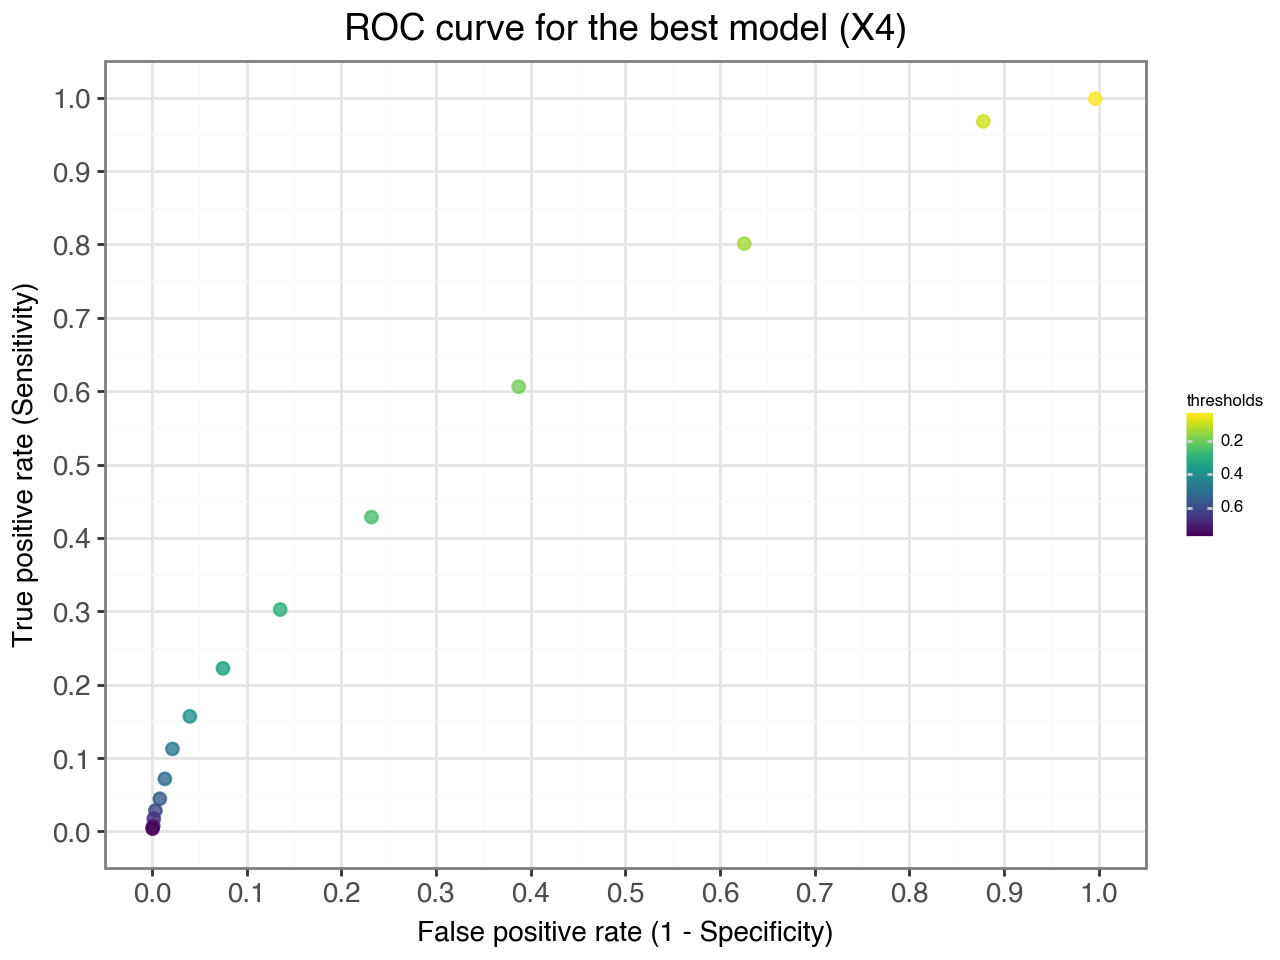

In [88]:
ggplot(tpr_fpr_for_thresholds, aes(x = 'false_positive_rates', y = 'true_positive_rates', color='thresholds'))\
        + labs(
            x = "False positive rate (1 - Specificity)", 
            y = "True positive rate (Sensitivity)",
            title = 'ROC curve for the best model (X4)'
        )\
        + geom_point(size=2, alpha=0.8) + scale_color_continuous(trans = 'reverse')\
        + scale_x_continuous(limits=(0,1), breaks = seq(0, 1.01, by = 0.1))\
        + scale_y_continuous(limits=(0,1), breaks = seq(0, 1.01, by = 0.1))\
        + theme_bw()\
        +theme(legend_position="right",
            axis_text=element_text(size=10),
            axis_title=element_text(size=10),
            legend_text = element_text(size = 6),
            legend_title = element_text(size = 6),
            legend_key_size=6)

In [89]:
%matplotlib inline

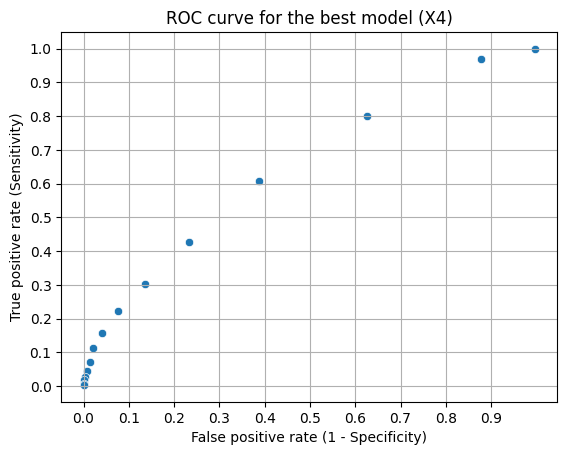

In [90]:
ax = sns.scatterplot(
    data = tpr_fpr_for_thresholds,
    x = 'false_positive_rates', 
    y = 'true_positive_rates', 
    marker = 'o')
ax.set_title('ROC curve for the best model (X4)')
ax.set_xlabel("False positive rate (1 - Specificity)"), 
ax.set_ylabel("True positive rate (Sensitivity)")
ax.set_xticks([x/10 for x in range(0,10,1)])
ax.set_yticks([x/10 for x in range(0,11,1)])
ax.grid(True);

**continuous ROC on holdout with best model (Logit 4)**

*ggplot*

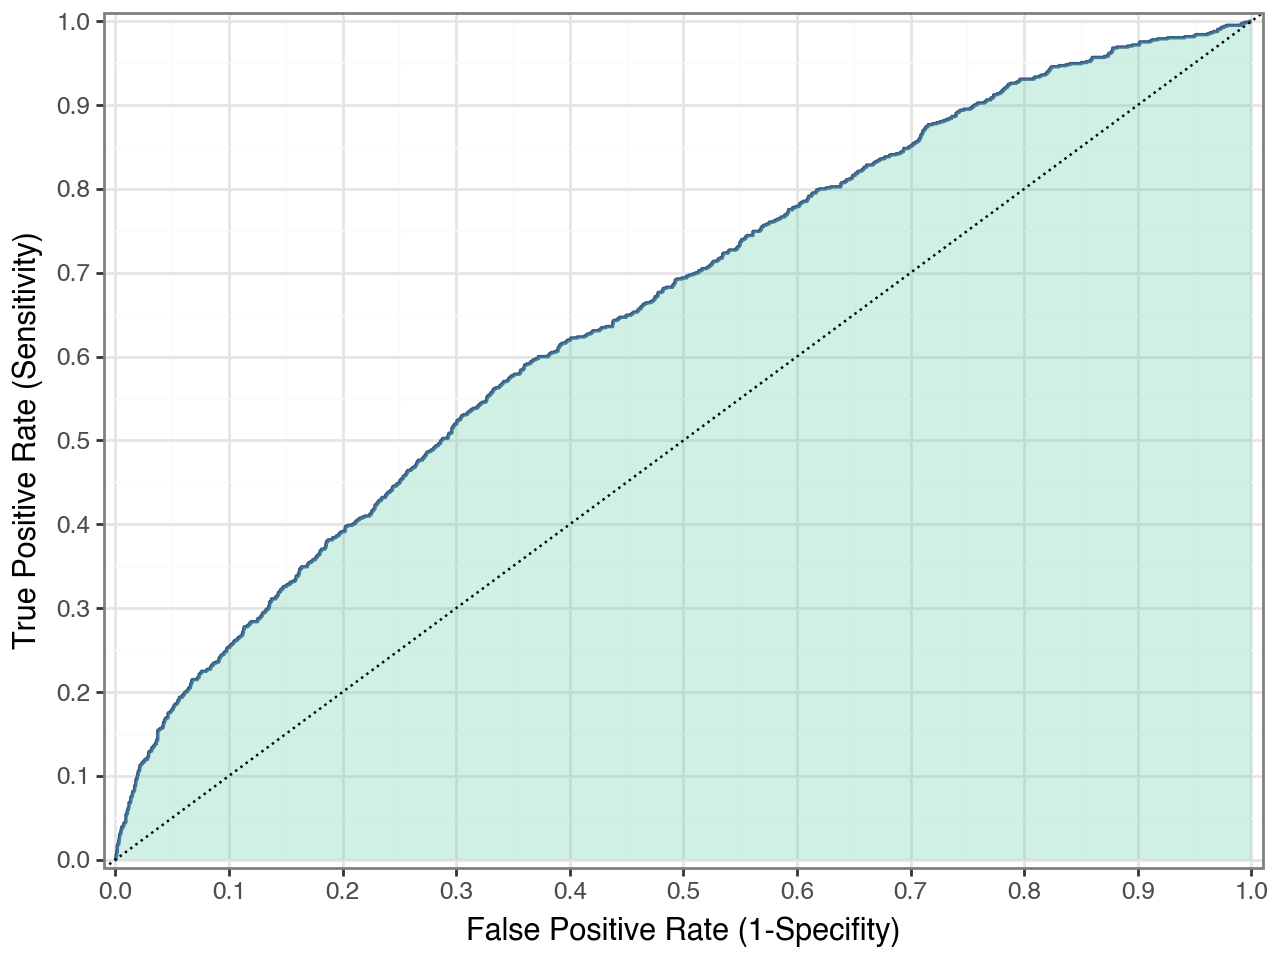

In [91]:
create_roc_plot(y_holdout, logit_predicted_probabilities_holdout)

*seaborn*

In [92]:
fpr, tpr, thresholds = roc_curve(y_holdout, logit_predicted_probabilities_holdout)

In [93]:
df_ = pd.DataFrame({
    'fpr': fpr,
    'tpr': tpr,
    'thresholds': thresholds
})

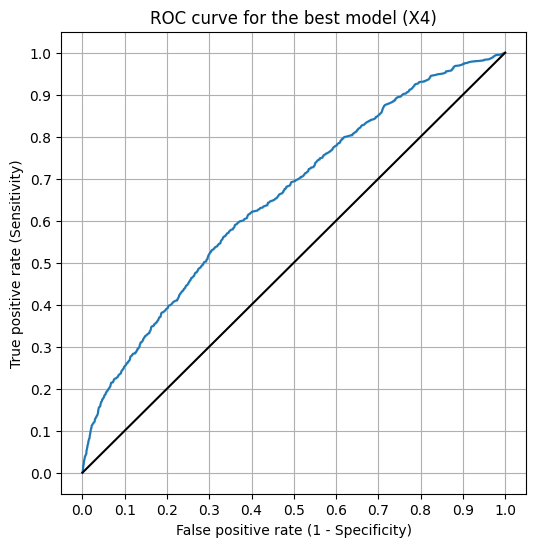

In [94]:
plt.figure(figsize = (6,6))
ax = sns.lineplot(
    data = df_,
    x = fpr, 
    y = tpr)
ax.set_title('ROC curve for the best model (X4)')
ax.set_xlabel("False positive rate (1 - Specificity)"), 
ax.set_ylabel("True positive rate (Sensitivity)")
ax.set_xticks([x/10 for x in range(0,11,1)])
ax.set_yticks([x/10 for x in range(0,11,1)])
ax.plot(df_.fpr, df_.fpr, color = 'k')
ax.grid(True);

**Confusion table with different tresholds**

fast growth: the threshold 0.5 is used to convert probabilities to binary classes

In [95]:
logit_class_prediction = best_model.predict(best_model_X_holdout)

values, counts = np.unique(logit_class_prediction.tolist(), return_counts=True)
print(values[0],' (no fast growth): ',counts[0])
print(values[1],' (fast growth): ',counts[1])

0  (no fast growth):  3708
1  (fast growth):  99


confusion matrix: summarize different type of errors and successfully predicted cases   
positive = "yes": explicitly specify the positive case

In [96]:
cm_object1 = confusion_matrix(y_holdout, logit_class_prediction, labels=[0,1])
cm1 = pd.DataFrame(cm_object1, 
    index=['Actual no fast growth', 'Actual fast growth'], 
    columns=['Predicted no fast growth', 'Predicted fast growth'])
cm1

,Predicted no fast growth,Predicted fast growth
Actual no fast growth,2956,41
Actual fast growth,752,58


Applying different thresholds

- 0.5 same as before

In [97]:
holdout_prediction = np.where(logit_predicted_probabilities_holdout < 0.5, 0, 1)
cm_object1b = confusion_matrix(y_holdout, holdout_prediction, labels=[0,1])
cm1b = pd.DataFrame(cm_object1b, 
    index=['Actual no fast growth', 'Actual fast growth'], 
    columns=['Predicted no fast growth', 'Predicted fast growth'])
cm1b

,Predicted no fast growth,Predicted fast growth
Actual no fast growth,2956,41
Actual fast growth,752,58


In [98]:
print(f'FPR: {round(cm1b.iloc[0,1] / cm1b.iloc[0].sum(), 3)}')

FPR: 0.014


- a sensible choice: mean of predicted probabilities

In [99]:
mean_predicted_fast_growth_prob = np.mean(logit_predicted_probabilities_holdout)
round(mean_predicted_fast_growth_prob, 3)

0.211

In [100]:
holdout_prediction = np.where(logit_predicted_probabilities_holdout < mean_predicted_fast_growth_prob, 0, 1)
cm_object2 = confusion_matrix(y_holdout, holdout_prediction, labels=[0,1])
cm2 = pd.DataFrame(cm_object2, 
    index=['Actual no fast growth', 'Actual fast growth'], 
    columns=['Predicted no fast growth', 'Predicted fast growth'])
cm2

,Predicted no fast growth,Predicted fast growth
Actual no fast growth,1960,1037
Actual fast growth,347,463


In [101]:
print(f'FPR: {round(cm2.iloc[0,1] / cm2.iloc[0].sum(), 3)}')

FPR: 0.346


#### Calibration curve

How well do estimated vs actual event probabilities relate to each other?

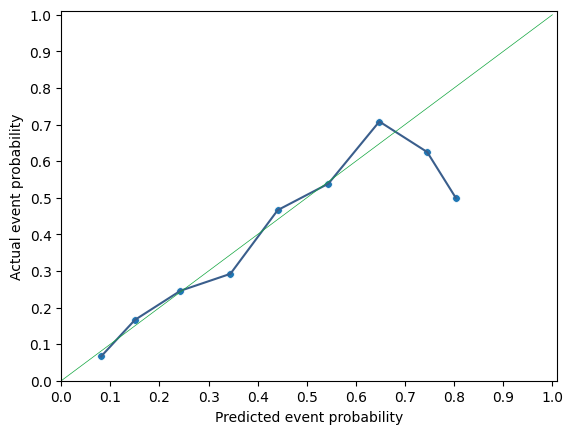

In [102]:
holdout = pd.concat([best_model_X_holdout, y_holdout], axis=1)
holdout["best_logit_no_loss_pred"] = logit_predicted_probabilities_holdout
create_calibration_plot(
    holdout, 
    # file_name = "ch17-figure-1-logit-m4-calibration",
    prob_var='best_logit_no_loss_pred', 
    actual_var='fast_growth',
    y_lab="Actual event probability", 
    n_bins=10, 
    breaks=None)

### AUC using a loss function

**Loss function**: relative cost of of a false negative classification (as compared with a false positive classification)

In [103]:
FP = 1
FN = 10
cost = FN/FP

# the prevalence, or the proportion of cases in the population (n.cases/(n.controls+n.cases))
prevelance = y_train.sum()/len(y_train)
prevelance

0.2096657692560247

**Draw ROC Curve and find optimal threshold with loss function**

The optimal cut-off is the threshold that maximizes the distance to the identity (diagonal) line

In [104]:
best_thresholds_cv = dict()
expected_loss_cv = dict()
fold5_threshold = dict()
fold5_expected_loss = dict()
fold5_all_coords = dict()

for i, model_name in enumerate(logit_models):
    best_thresholds = []
    expected_loss =[]
    if model_name != 'LASSO':
        X = logit_model_vars[i]
        c_index = 0
    else:
        X = normalized_logitvars
        c_index = best_lambda_i
    fold = 0
    for train_index, test_index in k.split(X):
        X_fold = X.iloc[test_index,:]
        y_fold = y_train.iloc[test_index]
        pred_fold = generate_fold_prediction(logit_models[model_name], X_fold, fold, c_index)
        false_pos_rate, true_pos_rate, thresholds = roc_curve(y_fold, pred_fold)
        optimal_threshold = sorted(list(zip(
            np.abs(true_pos_rate + (1 - prevelance)/(cost * prevelance)*(1-false_pos_rate)),\
                                       thresholds)), key=lambda i: i[0], reverse=True)[0][1]
        best_thresholds.append(optimal_threshold)
        threshold_prediction = np.where(pred_fold < optimal_threshold, 0, 1)
        tn, fp, fn, tp = confusion_matrix(y_fold, threshold_prediction, labels=[0,1]).ravel()
        curr_exp_loss = (fp*FP + fn*FN)/len(y_fold)
        expected_loss.append(curr_exp_loss)
        fold = fold+1

    best_thresholds_cv[model_name] = np.mean(best_thresholds)
    expected_loss_cv[model_name] = np.mean(expected_loss)

    # for fold #5
    fold5_threshold[model_name] = optimal_threshold
    fold5_expected_loss[model_name] = curr_exp_loss

    all_coords = pd.DataFrame({
        'false_pos': false_pos_rate*sum(y_fold == 0),
        'true_pos': true_pos_rate*sum(y_fold == 1),
        'false_neg': sum(y_fold == 1) - true_pos_rate*sum(y_fold == 1),
        'true_neg': sum(y_fold == 0) - false_pos_rate*sum(y_fold == 0),
        'pos': sum(y_fold == 1),
        'neg': sum(y_fold == 0),
        'n': len(y_fold),
        'thresholds': thresholds
    })
    
    fold5_all_coords[model_name] = all_coords

In [105]:
fold5_all_coords['X1']

,false_pos,true_pos,false_neg,true_neg,pos,neg,n,thresholds
0,0.0,0.0,635.0,2410.0,635,2410,3045,inf
1,0.0,1.0,634.0,2410.0,635,2410,3045,0.594719
2,1.0,1.0,634.0,2409.0,635,2410,3045,0.525281
3,1.0,2.0,633.0,2409.0,635,2410,3045,0.506176
4,2.0,2.0,633.0,2408.0,635,2410,3045,0.470134
...,...,...,...,...,...,...,...,...
987,2384.0,633.0,2.0,26.0,635,2410,3045,0.124755
988,2384.0,634.0,1.0,26.0,635,2410,3045,0.124561
989,2398.0,634.0,1.0,12.0,635,2410,3045,0.121431
990,2398.0,635.0,0.0,12.0,635,2410,3045,0.121149


In [106]:
logit_summary2 = pd.DataFrame(best_thresholds_cv.items(),columns=['Model', 'Avg of optimal thresholds'])
logit_summary2['Threshold for Fold5'] = fold5_threshold.values()
logit_summary2['Avg expected loss'] = expected_loss_cv.values()
logit_summary2['Expected loss for Fold5'] = fold5_expected_loss.values()

In [107]:
logit_summary2

,Model,Avg of optimal thresholds,Threshold for Fold5,Avg expected loss,Expected loss for Fold5
0,X1,0.129871,0.131512,0.782849,0.783251
1,X2,0.084622,0.122629,0.783571,0.782923
2,X3,0.092586,0.114657,0.777793,0.780624
3,X4,0.075749,0.087833,0.777136,0.774384
4,X5,0.086776,0.091405,0.773787,0.769130
5,LASSO,0.073203,0.105463,0.776150,0.769130


### Loss plot based on Fold5 in CV

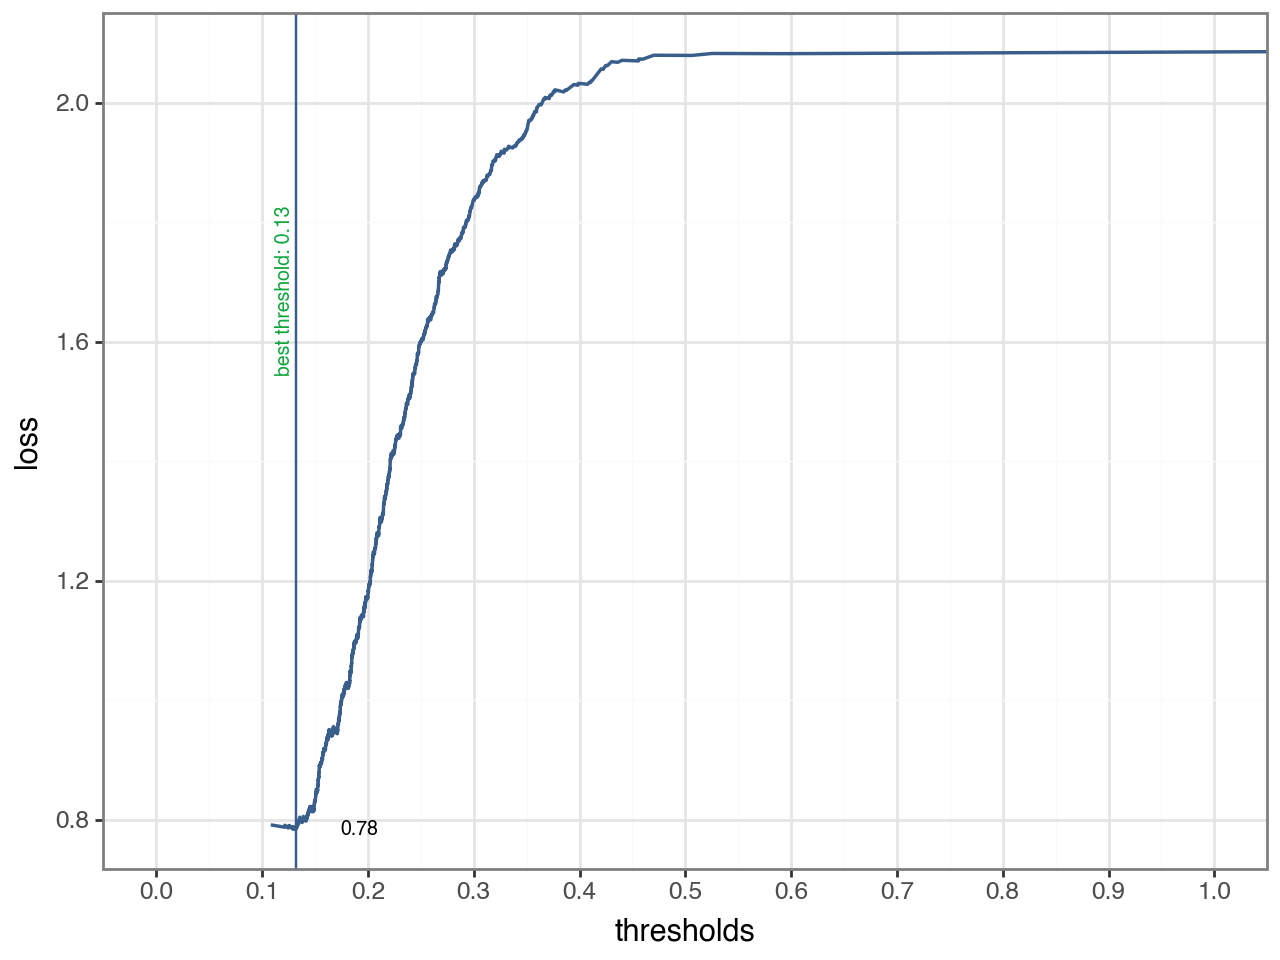

In [108]:
model_to_plot = 'X1'
create_loss_plot(
    fold5_all_coords[model_to_plot], 
    fold5_threshold[model_to_plot], 
    fold5_expected_loss[model_to_plot])

#### ROC plot plot based on Fold5 in CV

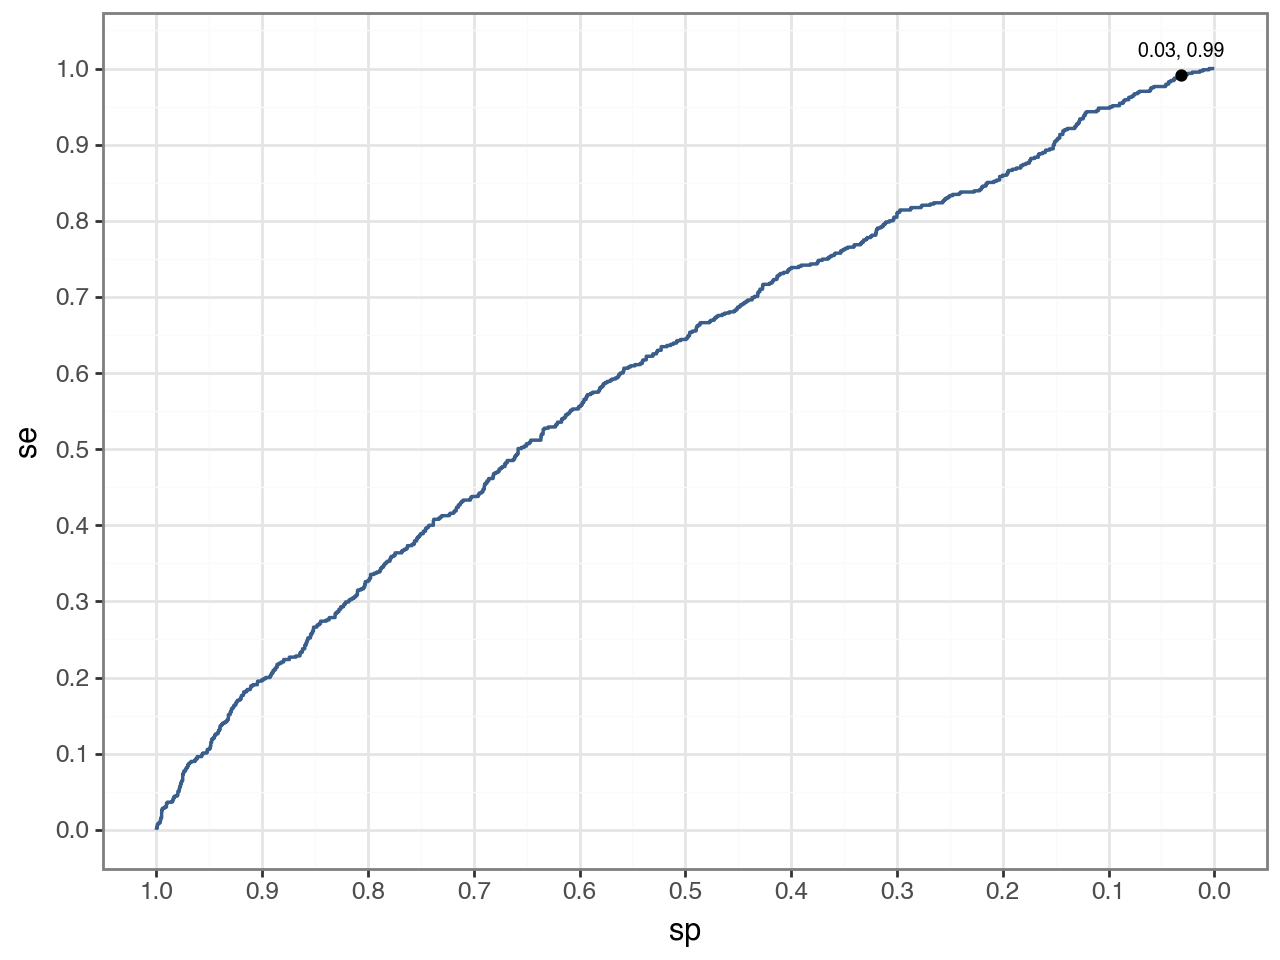

In [109]:
model_to_plot = 'X1'
create_roc_plot_with_optimal(fold5_all_coords[model_to_plot], fold5_threshold[model_to_plot])

#### Pick best model based on average expected loss

### X4

In [110]:
best_logit_optimal_treshold = best_thresholds_cv["X4"]
best_logit_optimal_treshold

0.07574895464648398

**Get expected loss on holdout**

In [111]:
holdout_treshold = np.where(logit_predicted_probabilities_holdout < best_logit_optimal_treshold, 0, 1)
tn, fp, fn, tp = confusion_matrix(y_holdout, holdout_treshold, labels=[0,1]).ravel()
expected_loss_holdout = (fp*FP + fn*FN)/len(y_holdout)
round(expected_loss_holdout, 3)

0.789

In [112]:
cm_object3 = confusion_matrix(y_holdout, holdout_treshold, labels=[0,1])
cm3 = pd.DataFrame(cm_object3, 
    index=['Actual no fast growth', 'Actual fast growth'], 
    columns=['Predicted no fast growth', 'Predicted fast growth'])
cm3

,Predicted no fast growth,Predicted fast growth
Actual no fast growth,105,2892
Actual fast growth,11,799


In [113]:
print(f'FPR: {round(cm3.iloc[0,1] / cm3.iloc[0].sum(), 3)}')

FPR: 0.965


### Prediction with random forest 

In [114]:
rfvars_train = rfvars.iloc[index_train]
rfvars_holdout = rfvars.iloc[index_holdout]

In [115]:
rfvars_train.columns

Index(['sales_mil', 'd1_sales_mil_log', 'curr_assets', 'curr_liab',
       'extra_exp', 'extra_inc', 'extra_profit_loss', 'fixed_assets',
       'inc_bef_tax', 'intang_assets', 'inventories', 'liq_assets',
       'material_exp', 'personnel_exp', 'profit_loss_year', 'sales',
       'share_eq', 'subscribed_cap', 'female', 'ceo_age', 'flag_high_ceo_age',
       'flag_low_ceo_age', 'flag_miss_ceo_age', 'ceo_count', 'labor_avg_mod',
       'flag_miss_labor_avg', 'foreign_management', 'balsheet_flag',
       'balsheet_length', 'balsheet_notfullyear', 'age', 'age2', 'new',
       'C(ind2_cat)[26.0]', 'C(ind2_cat)[27.0]', 'C(ind2_cat)[28.0]',
       'C(ind2_cat)[29.0]', 'C(ind2_cat)[30.0]', 'C(ind2_cat)[33.0]',
       'C(ind2_cat)[55.0]', 'C(ind2_cat)[56.0]', 'C(m_region_loc)[East]',
       'C(m_region_loc)[West]', 'C(urban_m)[2.0]', 'C(urban_m)[3.0]'],
      dtype='object')

#### Graph example

<Figure size 640x480 with 0 Axes>

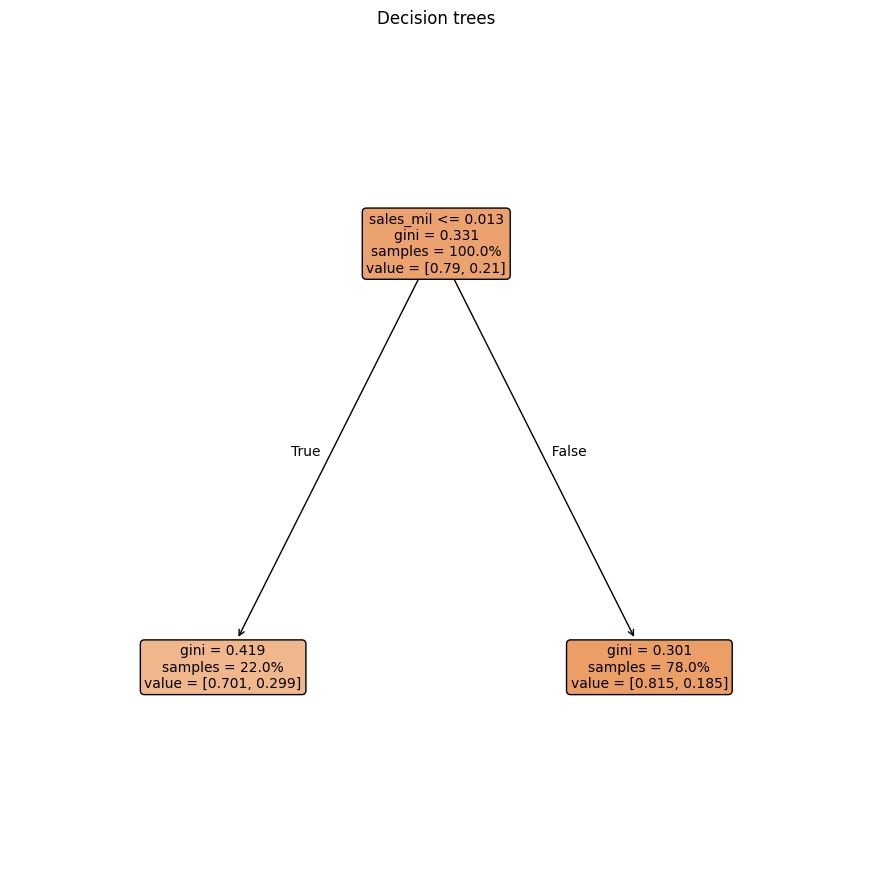

CPU times: user 473 ms, sys: 77.9 ms, total: 550 ms
Wall time: 243 ms


In [116]:
%%time 
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

data_for_graph = rfvars_train[['sales_mil','profit_loss_year','foreign_management']]
rf_for_graph = DecisionTreeClassifier(
    ccp_alpha=0.0028, 
    min_samples_leaf=100, 
    max_depth=3, 
    random_state=41).fit(
    data_for_graph, 
    y_train)

plt.figure()
plt.figure(figsize=(11,11))
plot_tree(rf_for_graph, 
          feature_names = data_for_graph.columns, 
          filled=True, 
          rounded=True, 
          proportion=True, 
          fontsize = 10)
plt.title("Decision trees")
plt.show() 

### Probability forest

A random forest is a meta estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting. The sub-sample size is controlled with the `max_samples` parameter if `bootstrap = True` (default), otherwise the whole dataset is used to build each tree.
- `max_features`: number of features to consider when looking for the best split
- `min_samples_fit`: the minimum number of samples required`to split an internal node

In [117]:
grid = {'max_features': [5, 6, 7],
        'criterion':['gini'],
        'min_samples_split': [11, 16]}

In [118]:
prob_forest = RandomForestClassifier(
    random_state=20240205, 
    n_estimators=500, 
    oob_score=True)

prob_forest_grid = GridSearchCV(
    prob_forest, 
    grid, 
    cv=k, 
    refit='accuracy',
    scoring = ['accuracy', 'roc_auc', 'neg_brier_score'], 
    n_jobs=-1)

In [119]:
%%time
prob_forest_fit = prob_forest_grid.fit(rfvars_train, y_train)

CPU times: user 35 s, sys: 1.08 s, total: 36.1 s
Wall time: 4min 14s


**CV summary table**

In [120]:
prob_forest_fit.cv_results_

{'mean_fit_time': array([43.34833331, 44.75254025, 56.11651731, 51.61975474, 57.39357395,
        52.5224154 ]),
 'std_fit_time': array([0.38105278, 2.93324259, 0.55313022, 2.21223007, 1.80828708,
        1.54514765]),
 'mean_score_time': array([1.49393682, 1.20539541, 1.47771797, 1.28632331, 1.04870324,
        0.99345675]),
 'std_score_time': array([0.08764674, 0.14248585, 0.22999861, 0.40142651, 0.06116899,
        0.32402363]),
 'param_criterion': masked_array(data=['gini', 'gini', 'gini', 'gini', 'gini', 'gini'],
              mask=[False, False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'param_max_features': masked_array(data=[5, 5, 6, 6, 7, 7],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'param_min_samples_split': masked_array(data=[11, 16, 11, 16, 11, 16],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'params': [{'criterion': 'gini', 'max_feature

Our grid has 3x2=6 elements. 

In [121]:
cv_accuracy = np.zeros([6])
for i in range(5):
    cv_accuracy = cv_accuracy + prob_forest_fit.cv_results_['split' + str(i) + '_test_accuracy']
cv_accuracy = cv_accuracy/5
cv_accuracy

array([0.79788575, 0.79795148, 0.79775445, 0.79808277, 0.79670385,
       0.79762311])

In [122]:
prob_forest_fit.best_score_

0.7980827745774425

In [123]:
cv_auc = np.zeros([6])
for i in range(5):
    cv_auc = cv_auc + prob_forest_fit.cv_results_['split' + str(i) + '_test_roc_auc']
cv_auc = cv_auc/5
cv_auc

array([0.67132377, 0.67110335, 0.66947135, 0.66886701, 0.66762598,
       0.67022247])

In [124]:
cv_rmse = np.zeros([6])
for i in range(5):
    cv_rmse = cv_rmse +np.sqrt(-1*(prob_forest_fit.cv_results_['split' + str(i) + '_test_neg_brier_score'])).tolist()
cv_rmse = cv_rmse/5
cv_rmse

array([0.39130214, 0.39125261, 0.39167764, 0.3916138 , 0.39206673,
       0.39161878])

In [125]:
prob_forest_cv_results = pd.DataFrame({
    'max_features': prob_forest_fit.cv_results_['param_max_features'],
    'min_samples_split': prob_forest_fit.cv_results_['param_min_samples_split'],
    'cv_accuracy': cv_accuracy,
    'cv_auc': cv_auc,
    'cv_rmse': cv_rmse
})

In [126]:
prob_forest_cv_results

,max_features,min_samples_split,cv_accuracy,cv_auc,cv_rmse
0,5,11,0.797886,0.671324,0.391302
1,5,16,0.797951,0.671103,0.391253
2,6,11,0.797754,0.669471,0.391678
3,6,16,0.798083,0.668867,0.391614
4,7,11,0.796704,0.667626,0.392067
5,7,16,0.797623,0.670222,0.391619


**Optimal parameter values**

In [127]:
best_max_features = prob_forest_fit.best_params_['max_features']
best_min_sample_split = prob_forest_fit.best_params_['min_samples_split']
prob_forest_fit.best_params_

{'criterion': 'gini', 'max_features': 6, 'min_samples_split': 16}

**Average RMSE and AUC over folds**

In [128]:
prob_forest_best_results = prob_forest_cv_results[
    (prob_forest_cv_results.max_features == best_max_features) & 
    (prob_forest_cv_results.min_samples_split == best_min_sample_split)]
prob_forest_best_results_index = prob_forest_best_results.index.values[0]

CV_RMSE['rf_p'] = prob_forest_best_results.cv_rmse.values[0]
CV_AUC['rf_p'] = prob_forest_best_results.cv_auc.values[0]

In [129]:
CV_RMSE

{'X1': 0.40281544985036766,
 'X2': 0.3979057523201194,
 'X3': 0.395766311884973,
 'X4': 0.39396384993836736,
 'X5': 0.393838127199205,
 'LASSO': 0.39389806158055995,
 'rf_p': 0.39161380412210756}

In [130]:
CV_AUC

{'X1': 0.5960225467138429,
 'X2': 0.6362292331174257,
 'X3': 0.6525460470798944,
 'X4': 0.660594603980189,
 'X5': 0.6637019769274571,
 'LASSO': 0.6626097710067285,
 'rf_p': 0.6688670116912739}

**Get fold level RMSE and AUC**

In [131]:
CV_RMSE_folds_rf_p = list()

for i in range(5):
    rmse = np.sqrt(-1*(prob_forest_fit.cv_results_['split' + str(i) + '_test_neg_brier_score'])).tolist()[prob_forest_best_results_index]
    CV_RMSE_folds_rf_p.append(rmse)

CV_RMSE_folds['rf_p'] = CV_RMSE_folds_rf_p

CV_AUC_folds_rf_p = list()

for i in range(5):
    rmse = prob_forest_fit.cv_results_['split' + str(i) + '_test_roc_auc'][prob_forest_best_results_index]
    CV_AUC_folds_rf_p.append(rmse)

CV_AUC_folds['rf_p'] = CV_AUC_folds_rf_p

In [132]:
pd.DataFrame(CV_AUC_folds)

,X1,X2,X3,X4,X5,LASSO,rf_p
0,0.599907,0.647159,0.672293,0.678637,0.681123,0.678767,0.681403
1,0.615801,0.656176,0.670859,0.674148,0.682773,0.677530,0.690830
2,0.578433,0.629622,0.640479,0.648365,0.647353,0.649087,0.654700
3,0.582520,0.608205,0.627748,0.639315,0.640574,0.640864,0.656963
4,0.603452,0.639984,0.651352,0.662507,0.666687,0.666802,0.660438


**Now use loss function and search for best thresholds and expected loss over folds**

In [133]:
best_thresholds = list()
expected_loss = list()

fold = 0
for train_index, test_index in k.split(rfvars_train):
    X_fold = rfvars_train.iloc[test_index,:]
    y_fold = y_train.iloc[test_index]
    
    X_fold_train = rfvars_train.iloc[train_index,:]
    y_fold_train = y_train.iloc[train_index]
    
    prob_forest_best = RandomForestClassifier(
        random_state=20240205, 
        n_estimators=500, 
        oob_score=True,
        criterion = 'gini', 
        max_features = best_max_features, min_samples_split = best_min_sample_split)
    
    prob_forest_best_fold = prob_forest_best.fit(X_fold_train, y_fold_train)
    pred_fold = prob_forest_best_fold.predict_proba(X_fold)[:,1]

    false_pos_rate, true_pos_rate, threshold = roc_curve(y_fold, pred_fold)
    
    best_threshold = sorted(
        list(
            zip(
                np.abs(
                    true_pos_rate + (1 - prevelance)/(cost * prevelance)*(1-false_pos_rate)
                ),
                threshold
            )
        ), 
        key=lambda x: x[0], reverse=True)[0][1]
    
    best_thresholds.append(best_threshold)
    
    threshold_prediction = np.where(pred_fold < best_threshold, 0, 1)
    tn, fp, fn, tp = confusion_matrix(y_fold, threshold_prediction, labels=[0,1]).ravel()
    curr_exp_loss = (fp*FP + fn*FN)/len(y_fold)
    expected_loss.append(curr_exp_loss)

In [134]:
best_thresholds

[0.09577117610155528,
 0.10791431593675167,
 0.09413608922914372,
 0.07483893016684039,
 0.09180334153445208]

In [135]:
expected_loss

[0.7445830597504924,
 0.7452396585686146,
 0.7695338148391333,
 0.7793827971109653,
 0.7494252873563219]

In [136]:
fold5_threshold_rf = best_threshold
fold5_expected_loss_rf = curr_exp_loss

all_coords_rf = pd.DataFrame({
    'false_pos': false_pos_rate*sum(y_fold == 0),
    'true_pos': true_pos_rate*sum(y_fold == 1),
    'false_neg': sum(y_fold == 1) - true_pos_rate*sum(y_fold == 1),
    'true_neg': sum(y_fold == 0) - false_pos_rate*sum(y_fold == 0),
    'pos': sum(y_fold == 1),
    'neg': sum(y_fold == 0),
    'n': len(y_fold),
    'thresholds': threshold
})

all_coords_rf

,false_pos,true_pos,false_neg,true_neg,pos,neg,n,thresholds
0,0.0,0.0,635.0,2410.0,635,2410,3045,inf
1,0.0,1.0,634.0,2410.0,635,2410,3045,0.869080
2,0.0,28.0,607.0,2410.0,635,2410,3045,0.621318
3,2.0,28.0,607.0,2408.0,635,2410,3045,0.617617
4,2.0,29.0,606.0,2408.0,635,2410,3045,0.615793
...,...,...,...,...,...,...,...,...
935,2402.0,633.0,2.0,8.0,635,2410,3045,0.037439
936,2402.0,634.0,1.0,8.0,635,2410,3045,0.035495
937,2405.0,634.0,1.0,5.0,635,2410,3045,0.030733
938,2405.0,635.0,0.0,5.0,635,2410,3045,0.028022


In [137]:
fold5_threshold_rf = best_threshold
fold5_expected_loss_rf = curr_exp_loss

all_coords_rf = pd.DataFrame({
    'false_pos': false_pos_rate*sum(y_fold == 0),
    'true_pos': true_pos_rate*sum(y_fold == 1),
    'false_neg': sum(y_fold == 1) - true_pos_rate*sum(y_fold == 1),
    'true_neg': sum(y_fold == 0) - false_pos_rate*sum(y_fold == 0),
    'pos': sum(y_fold == 1),
    'neg': sum(y_fold == 0),
    'n': len(y_fold),
    'thresholds': threshold
})

In [138]:
expected_loss_cv['rf_p'] = np.mean(expected_loss)
best_thresholds_cv['rf_p'] = np.mean(best_thresholds)

In [139]:
rf_summary = pd.DataFrame(
    {'CV RMSE': [round(CV_RMSE['rf_p'], 3)],
     'CV AUC': [round(CV_AUC['rf_p'], 3)],
     'Avg of optimal thresholds': [round(best_thresholds_cv['rf_p'], 3)],
     'Threshold for Fold5': [round(best_threshold, 3)],
     'Avg expected loss': [round(expected_loss_cv['rf_p'], 3)],
     'Expected loss for Fold5': [round(curr_exp_loss, 3)]})

rf_summary

,CV RMSE,CV AUC,Avg of optimal thresholds,Threshold for Fold5,Avg expected loss,Expected loss for Fold5
0,0.392,0.669,0.093,0.092,0.758,0.749


**Plots based on Fold5 in CV**

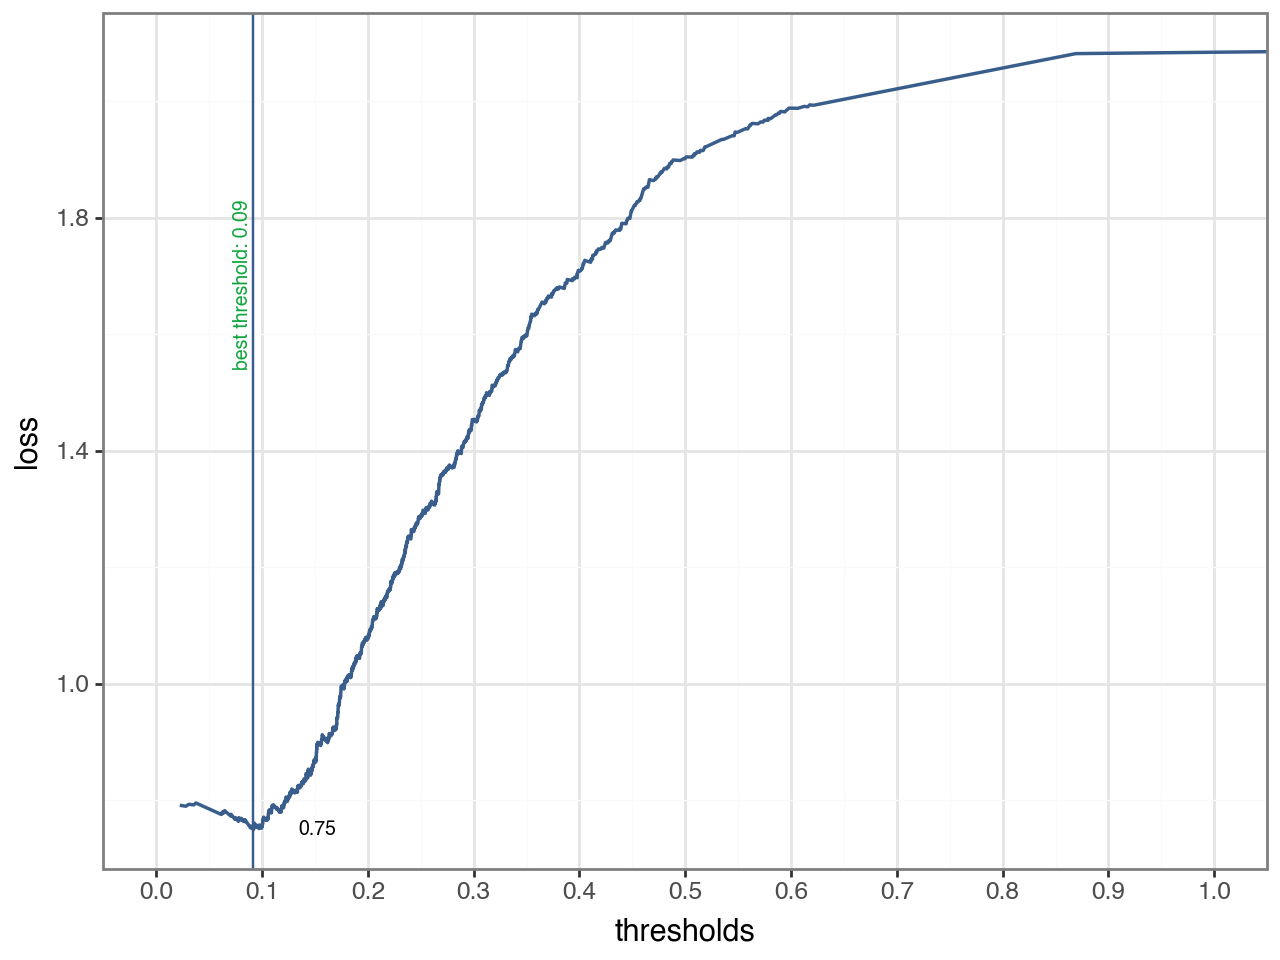

In [140]:
create_loss_plot(all_coords_rf, fold5_threshold_rf, fold5_expected_loss_rf)

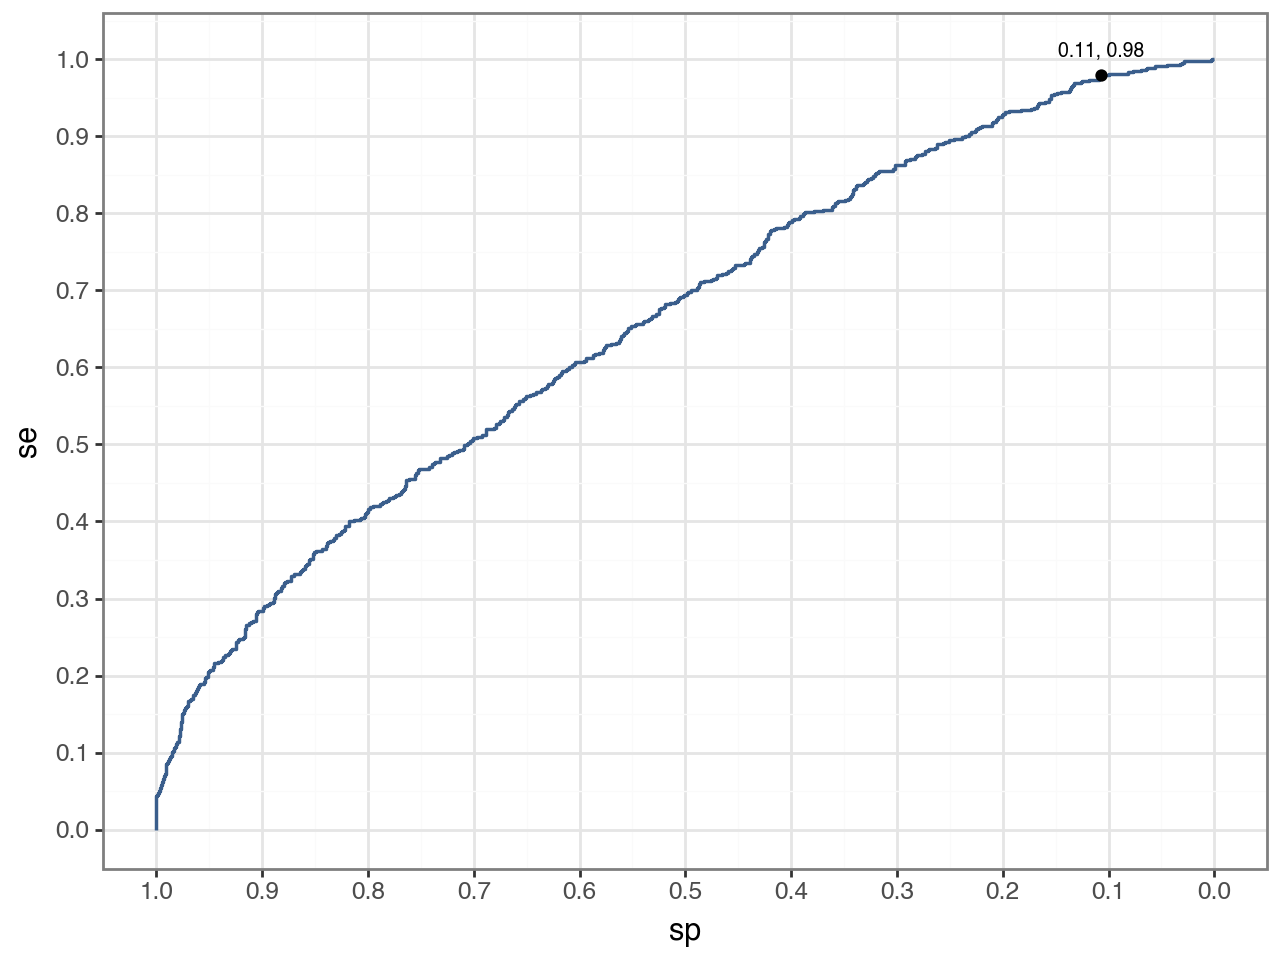

In [141]:
create_roc_plot_with_optimal(all_coords_rf, fold5_threshold_rf)

**Take model to holdout and estimate RMSE, AUC and expected loss**

In [142]:
prob_forest_fit_best = prob_forest_fit.best_estimator_
rf_predicted_probabilities_holdout = prob_forest_fit_best.predict_proba(rfvars_holdout)[:,1]
rmse_rf = np.sqrt(mean_squared_error(y_holdout, rf_predicted_probabilities_holdout))
round(rmse_rf, 3)

0.395

**ROC AUC  on holdout**

In [143]:
auc_rf = roc_auc_score(y_holdout, rf_predicted_probabilities_holdout)
round(auc_rf, 3)

0.664

**Expected loss on holdout**

In [144]:
holdout_treshold = np.where(rf_predicted_probabilities_holdout < best_thresholds_cv['rf_p'], 0, 1)
tn, fp, fn, tp = confusion_matrix(y_holdout, holdout_treshold, labels=[0,1]).ravel()
expected_loss_holdout = (fp*FP + fn*FN)/len(y_holdout)
round(expected_loss_holdout, 3)

0.767

In [145]:
import datetime
print(datetime.datetime.now())

2026-02-02 15:10:06.637414


### Getting probalbilities and classifications from RandomforestClassifier

- classes

In [146]:
prob_forest_best_fold.predict(rfvars_holdout)

array([0, 0, 0, ..., 0, 0, 0])

- probabilities

In [147]:
prob_forest_best_fold.predict_proba(rfvars_holdout)

array([[0.8850374 , 0.1149626 ],
       [0.82342974, 0.17657026],
       [0.69843975, 0.30156025],
       ...,
       [0.58885431, 0.41114569],
       [0.81349015, 0.18650985],
       [0.8684204 , 0.1315796 ]])

## Final results

In [148]:
nvars['rf_p'] = len(rfvars.columns)

In [149]:
summary_results = pd.DataFrame({"Model": list(nvars.keys()),
                              "Number of predictors": list(nvars.values()),
                              "CV RMSE": list(CV_RMSE.values()),
                              "CV AUC": list(CV_AUC.values()),
                              "CV threshold": list(best_thresholds_cv.values()),
                              "CV expected Loss": list(expected_loss_cv.values())
                               })

In [150]:
summary_results

,Model,Number of predictors,CV RMSE,CV AUC,CV threshold,CV expected Loss
0,X1,12,0.402815,0.596023,0.129871,0.782849
1,X2,19,0.397906,0.636229,0.084622,0.783571
2,X3,36,0.395766,0.652546,0.092586,0.777793
3,X4,80,0.393964,0.660595,0.075749,0.777136
4,X5,172,0.393838,0.663702,0.086776,0.773787
5,LASSO,131,0.393898,0.662610,0.073203,0.776150
6,rf_p,45,0.391614,0.668867,0.092893,0.757633


# Task 2

Manufacturing: These are codes in the 10–33 range (e.g., food production, textiles, machinery).

Services: These are usually codes in the 55–56 (Accommodation & Food) and 95–96 (Repair & Personal Services) ranges.

In [151]:
data["ind2_cat"].value_counts()

ind2_cat
56.0    11413
55.0     2061
28.0     1790
33.0     1772
26.0      994
27.0      599
29.0      259
30.0      148
Name: count, dtype: int64

In [153]:
# Group 1: Manufacturing (NACE 10-33)
df_manuf = data[data['ind2_cat'].between(10, 33)]

# Group 2: Services (Accommodation, Food, Repair)
df_serv = data[data['ind2_cat'].isin([55, 56, 95, 96])]

print(f"Manufacturing Sample Size: {len(df_manuf)}")
print(f"Services Sample Size: {len(df_serv)}")

Manufacturing Sample Size: 5562
Services Sample Size: 13474


In [155]:
# 1. SETUP: Define groups and parameters
groups = {
    "Manufacturing": data[data['ind2_cat'].between(10, 33)],
    "Services": data[data['ind2_cat'].isin([55, 56, 95, 96])]
}

# Use your notebook's specific settings
FP = 1
FN = 10
cost = FN/FP

# 2. THE LOOP: Process each group exactly like your notebook
industry_results = []

# 1. Identify the features that are NOT industry-specific or location-specific strings
# We want the original column names from your dataframe
raw_features = [col for col in data.columns if col in rfvars_train.columns and "ind2_cat" not in col and "region_loc" not in col and "urban_m" not in col]

# Add back the basic versions of those categorical variables if they exist
# Or just use the list of numeric/binary columns you know are safe
safe_features = ['sales_mil_log', 'age', 'foreign_management', 'ceo_age', 'curr_liab_bs', 'profit_loss_year'] 

# 2. Update the Loop
for name, df_group in groups.items():
    print(f"Processing {name}...")
    
    # FIX: Use safe_features instead of rfvars.columns
    X_ind = df_group[safe_features] 
    y_ind = df_group['fast_growth']
    
    # Split Train/Holdout
    X_train_ind, X_holdout_ind, y_train_ind, y_holdout_ind = train_test_split(
        X_ind, y_ind, test_size=0.2, random_state=20240205)
    
    # Calculate prevalence for this specific group
    prev = y_train_ind.sum() / len(y_train_ind)
    
    # Run the Probability Forest (using your best parameters found earlier)
    # best_max_features and best_min_sample_split from your previous output
    rf_industry = RandomForestClassifier(
        n_estimators=500, 
        max_features=best_max_features, 
        min_samples_split=best_min_sample_split,
        random_state=20240205)
    
    rf_industry.fit(X_train_ind, y_train_ind)
    
    # Get Holdout Predictions
    probs_holdout = rf_industry.predict_proba(X_holdout_ind)[:, 1]
    
    # Calculate AUC
    auc_score = roc_auc_score(y_holdout_ind, probs_holdout)
    
    # Calculate Optimal Threshold based on YOUR notebook's loss formula
    fpr, tpr, thresholds = roc_curve(y_holdout_ind, probs_holdout)
    optimal_t = sorted(list(zip(
        np.abs(tpr + (1 - prev)/(cost * prev)*(1-fpr)), thresholds)), 
        key=lambda i: i[0], reverse=True)[0][1]
    
    # Calculate Expected Loss on Holdout
    holdout_pred = np.where(probs_holdout < optimal_t, 0, 1)
    tn, fp, fn, tp = confusion_matrix(y_holdout_ind, holdout_pred, labels=[0,1]).ravel()
    exp_loss = (fp*FP + fn*FN) / len(y_holdout_ind)
    
    industry_results.append({
        'Industry': name,
        'N': len(df_group),
        'AUC': round(auc_score, 3),
        'Optimal Threshold': round(optimal_t, 3),
        'Expected Loss': round(exp_loss, 3)
    })

# 3. FINAL COMPARISON TABLE
task2_summary = pd.DataFrame(industry_results)
print(task2_summary)

Processing Manufacturing...
Processing Services...
        Industry      N    AUC  Optimal Threshold  Expected Loss
0  Manufacturing   5562  0.557              0.032          0.749
1       Services  13474  0.634              0.037          0.781
